In [1]:
# ============================================================
# DAILY RETURNS & ANNUALIZED RETURNS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("..")

fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

nav = pd.read_csv(
    BASE_DIR / "data/processed/02_nav_history_clean.csv"
)

benchmark = pd.read_csv(
    BASE_DIR / "data/raw/10_benchmark_indices.csv"
)

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
Benchmark: (8050, 3)


In [2]:
# Sort NAV data correctly
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

# Add scheme name
nav_returns = nav.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

display(nav_returns.head())

,amfi_code,date,nav,scheme_name,fund_house,category
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity


In [3]:
nav_returns["daily_return"] = (
    nav_returns
    .groupby("amfi_code")["nav"]
    .pct_change()
)

display(nav_returns.head(10))

,amfi_code,date,nav,scheme_name,fund_house,category,daily_return
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,NaN
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.010306
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,0.012865
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.011377
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.001210
5,100016,2022-01-10,510.7136,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.008639
6,100016,2022-01-11,513.5542,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,0.005562
7,100016,2022-01-12,512.3195,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.002404
8,100016,2022-01-13,510.2445,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.004050
9,100016,2022-01-14,514.3636,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,0.008073


In [4]:
print("Total rows:", len(nav_returns))

print(
    "Missing daily returns:",
    nav_returns["daily_return"].isna().sum()
)

print(
    "Daily return range:",
    nav_returns["daily_return"].min(),
    "to",
    nav_returns["daily_return"].max()
)

Total rows: 46000
Missing daily returns: 40
Daily return range: -0.058102013949189124 to 0.06471309359097144


In [5]:
nav_returns["annualized_return"] = (
    (1 + nav_returns["daily_return"]) ** 252 - 1
)

In [6]:
nav_returns["daily_return_pct"] = (
    nav_returns["daily_return"] * 100
)

nav_returns["annualized_return_pct"] = (
    nav_returns["annualized_return"] * 100
)

In [7]:
returns_computed = nav_returns[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "date",
        "nav",
        "daily_return",
        "annualized_return",
        "daily_return_pct",
        "annualized_return_pct"
    ]
].copy()

display(returns_computed.head())

,amfi_code,scheme_name,fund_house,category,date,nav,daily_return,annualized_return,daily_return_pct,annualized_return_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,2022-01-04,515.0971,-0.010306,-0.926503,-1.030568,-92.650257
2,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,2022-01-05,521.7239,0.012865,24.061674,1.286515,2406.167358
3,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,2022-01-06,515.7880,-0.011377,-0.944065,-1.137747,-94.406464
4,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,2022-01-07,515.1639,-0.001210,-0.262952,-0.120999,-26.295249


In [8]:
output_path = (
    BASE_DIR /
    "data/processed/returns_computed.csv"
)

returns_computed.to_csv(
    output_path,
    index=False
)

print(f"Saved to: {output_path}")

Saved to: ..\data\processed\returns_computed.csv


In [9]:
annualized_summary = (
    returns_computed
    .groupby(
        ["amfi_code", "scheme_name", "fund_house", "category"]
    )["annualized_return_pct"]
    .mean()
    .reset_index()
    .sort_values(
        "annualized_return_pct",
        ascending=False
    )
)

display(annualized_summary.head(10))

,amfi_code,scheme_name,fund_house,category,annualized_return_pct
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,726696.311032
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,207237.259441
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,101009.515320
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,100723.697624
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,65344.748677
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,33833.275452
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,11069.005027
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,9484.116486
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,8232.625585
26,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity,5751.120948


# Task 2 — CAGR Analysis

Calculate 1-year, 3-year and 5-year CAGR for all mutual fund schemes.


In [22]:
# TASK 2: CAGR REPORT
# 1-Year CAGR, 3-Year CAGR, and CAGR Till Date

import pandas as pd
import numpy as np

# Load NAV data
nav = pd.read_csv(BASE_DIR / "data/processed/02_nav_history_clean.csv")
fund_master = pd.read_csv(BASE_DIR / "data/processed/01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date")

    start_date = fund_data["date"].iloc[0]
    end_date = fund_data["date"].iloc[-1]

    start_nav = fund_data["nav"].iloc[0]
    end_nav = fund_data["nav"].iloc[-1]

    # Exact available period in years
    total_years = (end_date - start_date).days / 365.25

    # CAGR Till Date
    if total_years > 0 and start_nav > 0 and end_nav > 0:
        cagr_till_date = (
            (end_nav / start_nav) ** (1 / total_years) - 1
        ) * 100
    else:
        cagr_till_date = np.nan

    # ---------- 1 YEAR CAGR ----------
    target_1y = end_date - pd.DateOffset(years=1)

    previous_1y = fund_data[
        fund_data["date"] <= target_1y
    ]

    if len(previous_1y) > 0:
        nav_1y = previous_1y.iloc[-1]["nav"]

        cagr_1y = (
            (end_nav / nav_1y) ** (1 / 1) - 1
        ) * 100
    else:
        cagr_1y = np.nan

    # ---------- 3 YEAR CAGR ----------
    target_3y = end_date - pd.DateOffset(years=3)

    previous_3y = fund_data[
        fund_data["date"] <= target_3y
    ]

    if len(previous_3y) > 0:
        nav_3y = previous_3y.iloc[-1]["nav"]

        cagr_3y = (
            (end_nav / nav_3y) ** (1 / 3) - 1
        ) * 100
    else:
        cagr_3y = np.nan

    results.append({
        "amfi_code": amfi_code,
        "start_date": start_date,
        "end_date": end_date,
        "start_nav": start_nav,
        "end_nav": end_nav,
        "available_period_years": total_years,
        "CAGR_1Y_pct": cagr_1y,
        "CAGR_3Y_pct": cagr_3y,
        "CAGR_Till_Date_pct": cagr_till_date
    })

# Convert to DataFrame
cagr_report = pd.DataFrame(results)

# Add fund metadata
cagr_report = cagr_report.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "benchmark"
        ]
    ],
    on="amfi_code",
    how="left"
)

# Arrange columns
cagr_report = cagr_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "benchmark",
        "start_date",
        "end_date",
        "start_nav",
        "end_nav",
        "available_period_years",
        "CAGR_1Y_pct",
        "CAGR_3Y_pct",
        "CAGR_Till_Date_pct"
    ]
]

# Round values
cagr_report["CAGR_1Y_pct"] = cagr_report["CAGR_1Y_pct"].round(2)
cagr_report["CAGR_3Y_pct"] = cagr_report["CAGR_3Y_pct"].round(2)
cagr_report["CAGR_Till_Date_pct"] = cagr_report["CAGR_Till_Date_pct"].round(2)
cagr_report["available_period_years"] = cagr_report["available_period_years"].round(2)

# Save report
cagr_report.to_csv(
    BASE_DIR / "data/processed/cagr_report.csv",
    index=False
)

print("CAGR report created successfully.")
print("Shape:", cagr_report.shape)

display(cagr_report.head(10))

CAGR report created successfully.
Shape: (40, 13)


,amfi_code,scheme_name,fund_house,category,benchmark,start_date,end_date,start_nav,end_nav,available_period_years,CAGR_1Y_pct,CAGR_3Y_pct,CAGR_Till_Date_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,NIFTY 100 TRI,2022-01-03,2026-05-29,520.4608,583.6113,4.4,-2.22,1.29,2.64
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,CRISIL Short Term Bond Index,2022-01-03,2026-05-29,26.3169,31.8843,4.4,3.70,3.92,4.46
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,NIFTY Midcap 150 TRI,2022-01-03,2026-05-29,107.3758,342.0072,4.4,53.23,32.44,30.12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,NIFTY 100 TRI,2022-01-03,2026-05-29,305.0996,773.2939,4.4,47.92,28.97,23.54
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,BSE 250 SmallCap TRI,2022-01-03,2026-05-29,38.5736,53.9836,4.4,-23.99,-4.15,7.94
5,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,CRISIL Liquid Fund AI Index,2022-01-03,2026-05-29,310.7415,410.1021,4.4,7.24,6.32,6.51
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,NIFTY 50 TRI,2022-01-03,2026-05-29,89.8728,187.7797,4.4,20.21,19.67,18.23
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,NIFTY Midcap 150 TRI,2022-01-03,2026-05-29,119.2905,125.5640,4.4,-16.80,-0.77,1.17
8,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,NIFTY 500 TRI,2022-01-03,2026-05-29,191.0721,378.9657,4.4,13.58,25.56,16.84
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,NIFTY 100 TRI,2022-01-03,2026-05-29,42.8339,110.5554,4.4,33.98,22.65,24.05


In [23]:
print("CAGR Report Columns:")
print(cagr_report.columns.tolist())

print("\nAvailable Period:")
print(cagr_report["available_period_years"].describe())

print("\nTop 10 Funds by CAGR Till Date:")
display(
    cagr_report[
        [
            "scheme_name",
            "CAGR_1Y_pct",
            "CAGR_3Y_pct",
            "CAGR_Till_Date_pct"
        ]
    ]
    .sort_values("CAGR_Till_Date_pct", ascending=False)
    .head(10)
)

CAGR Report Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'benchmark', 'start_date', 'end_date', 'start_nav', 'end_nav', 'available_period_years', 'CAGR_1Y_pct', 'CAGR_3Y_pct', 'CAGR_Till_Date_pct']

Available Period:
count    40.0
mean      4.4
std       0.0
min       4.4
25%       4.4
50%       4.4
75%       4.4
max       4.4
Name: available_period_years, dtype: float64

Top 10 Funds by CAGR Till Date:


,scheme_name,CAGR_1Y_pct,CAGR_3Y_pct,CAGR_Till_Date_pct
25,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,32.83
21,SBI Small Cap Fund - Regular Plan - Growth,82.78,26.67,32.42
39,DSP Small Cap Fund - Regular - Growth,65.14,27.00,32.29
36,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,31.95
34,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,30.97
30,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,30.91
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,30.12
38,DSP Midcap Fund - Regular - Growth,21.48,26.87,29.58
16,Axis Midcap Fund - Regular - Growth,22.26,35.11,28.21
19,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,25.80


In [24]:
# TASK 3: SHARPE RATIO
# Annualized Sharpe Ratio using daily NAV returns

import pandas as pd
import numpy as np

# Load computed returns
returns = pd.read_csv(
    BASE_DIR / "data/processed/returns_computed.csv"
)

returns["date"] = pd.to_datetime(returns["date"])

# Assumed annual risk-free rate
risk_free_rate = 0.06

# Convert annual risk-free rate to daily rate
daily_rf = (1 + risk_free_rate) ** (1 / 252) - 1

sharpe_results = []

for amfi_code, fund_data in returns.groupby("amfi_code"):

    # Remove missing daily returns
    daily_returns = fund_data["daily_return"].dropna()

    # Excess return over daily risk-free rate
    excess_returns = daily_returns - daily_rf

    # Mean and standard deviation
    mean_excess_return = excess_returns.mean()
    std_daily_return = daily_returns.std()

    # Annualized Sharpe Ratio
    if std_daily_return != 0 and not np.isnan(std_daily_return):
        sharpe_ratio = (
            mean_excess_return / std_daily_return
        ) * np.sqrt(252)
    else:
        sharpe_ratio = np.nan

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe_ratio
    })

# Create DataFrame
sharpe_values = pd.DataFrame(sharpe_results)

# Add fund metadata
fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

sharpe_values = sharpe_values.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "risk_category"
        ]
    ],
    on="amfi_code",
    how="left"
)

# Arrange columns
sharpe_values = sharpe_values[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "risk_category",
        "Sharpe_Ratio"
    ]
]

# Round
sharpe_values["Sharpe_Ratio"] = (
    sharpe_values["Sharpe_Ratio"].round(3)
)

# Rank funds
sharpe_values["Sharpe_Rank"] = (
    sharpe_values["Sharpe_Ratio"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Sort
sharpe_values = sharpe_values.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

# Save
sharpe_values.to_csv(
    BASE_DIR / "data/processed/sharpe_values.csv",
    index=False
)

print("Sharpe ratio calculation completed.")
print("Number of funds:", len(sharpe_values))

display(sharpe_values.head(10))

Sharpe ratio calculation completed.
Number of funds: 40


,amfi_code,scheme_name,fund_house,category,risk_category,Sharpe_Ratio,Sharpe_Rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt,Low,1.857,1
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Moderate,1.496,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Moderately High,1.349,3
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,High,1.273,4
4,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Moderate,1.257,5
5,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt,Low,1.221,6
6,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,High,1.215,7
7,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,High,1.170,8
8,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Moderate,1.129,9
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,High,1.129,9


In [25]:
print("Top 10 Funds by Sharpe Ratio:")

display(
    sharpe_values[
        [
            "Sharpe_Rank",
            "scheme_name",
            "category",
            "Sharpe_Ratio"
        ]
    ].head(10)
)

print("\nSharpe Ratio Statistics:")
print(sharpe_values["Sharpe_Ratio"].describe())

Top 10 Funds by Sharpe Ratio:


,Sharpe_Rank,scheme_name,category,Sharpe_Ratio
0,1,ICICI Pru Liquid Fund - Regular - Growth,Debt,1.857
1,2,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.496
2,3,Kotak Flexicap Fund - Regular - Growth,Equity,1.349
3,4,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,1.273
4,5,SBI Bluechip Fund - Regular Plan - Growth,Equity,1.257
5,6,Kotak Liquid Fund - Regular - Growth,Debt,1.221
6,7,ICICI Pru Midcap Fund - Regular - Growth,Equity,1.215
7,8,DSP Midcap Fund - Regular - Growth,Equity,1.170
8,9,Nippon India Large Cap Fund - Regular - Growth,Equity,1.129
9,9,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.129



Sharpe Ratio Statistics:
count    40.000000
mean      0.684850
std       0.545382
min      -0.395000
25%       0.186250
50%       0.769500
75%       1.087000
max       1.857000
Name: Sharpe_Ratio, dtype: float64


In [26]:
# TASK 4: SORTINO RATIO
# Annualized Sortino Ratio using daily NAV returns

import pandas as pd
import numpy as np

# Load computed returns
returns = pd.read_csv(
    BASE_DIR / "data/processed/returns_computed.csv"
)

returns["date"] = pd.to_datetime(returns["date"])

# Annual risk-free rate
risk_free_rate = 0.06

# Convert annual risk-free rate to daily rate
daily_rf = (1 + risk_free_rate) ** (1 / 252) - 1

sortino_results = []

for amfi_code, fund_data in returns.groupby("amfi_code"):

    # Remove missing daily returns
    daily_returns = fund_data["daily_return"].dropna()

    # Excess returns
    excess_returns = daily_returns - daily_rf

    # Downside returns only
    downside_returns = excess_returns[excess_returns < 0]

    # Downside deviation
    if len(downside_returns) > 0:
        downside_deviation = np.sqrt(
            np.mean(downside_returns ** 2)
        )
    else:
        downside_deviation = np.nan

    # Mean excess return
    mean_excess_return = excess_returns.mean()

    # Annualized Sortino Ratio
    if (
        downside_deviation != 0
        and not np.isnan(downside_deviation)
    ):
        sortino_ratio = (
            mean_excess_return / downside_deviation
        ) * np.sqrt(252)
    else:
        sortino_ratio = np.nan

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino_ratio
    })

# Create DataFrame
sortino_values = pd.DataFrame(sortino_results)

# Load fund metadata
fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

# Add metadata
sortino_values = sortino_values.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "risk_category"
        ]
    ],
    on="amfi_code",
    how="left"
)

# Arrange columns
sortino_values = sortino_values[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "risk_category",
        "Sortino_Ratio"
    ]
]

# Round
sortino_values["Sortino_Ratio"] = (
    sortino_values["Sortino_Ratio"].round(3)
)

# Rank funds
sortino_values["Sortino_Rank"] = (
    sortino_values["Sortino_Ratio"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Sort highest to lowest
sortino_values = sortino_values.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

# Save
sortino_values.to_csv(
    BASE_DIR / "data/processed/sortino_values.csv",
    index=False
)

print("Sortino ratio calculation completed.")
print("Number of funds:", len(sortino_values))

display(sortino_values.head(10))

Sortino ratio calculation completed.
Number of funds: 40


,amfi_code,scheme_name,fund_house,category,risk_category,Sortino_Ratio,Sortino_Rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt,Low,1.929,1
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Moderate,1.512,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Moderately High,1.430,3
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,High,1.344,4
4,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Moderate,1.316,5
5,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,High,1.276,6
6,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt,Low,1.257,7
7,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,High,1.174,8
8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,High,1.161,9
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Moderate,1.155,10


In [27]:
print("Top 10 Funds by Sortino Ratio:")

display(
    sortino_values[
        [
            "Sortino_Rank",
            "scheme_name",
            "category",
            "Sortino_Ratio"
        ]
    ].head(10)
)

print("\nSortino Ratio Statistics:")
print(sortino_values["Sortino_Ratio"].describe())

Top 10 Funds by Sortino Ratio:


,Sortino_Rank,scheme_name,category,Sortino_Ratio
0,1,ICICI Pru Liquid Fund - Regular - Growth,Debt,1.929
1,2,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.512
2,3,Kotak Flexicap Fund - Regular - Growth,Equity,1.430
3,4,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,1.344
4,5,SBI Bluechip Fund - Regular Plan - Growth,Equity,1.316
5,6,ICICI Pru Midcap Fund - Regular - Growth,Equity,1.276
6,7,Kotak Liquid Fund - Regular - Growth,Debt,1.257
7,8,DSP Midcap Fund - Regular - Growth,Equity,1.174
8,9,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.161
9,10,Nippon India Large Cap Fund - Regular - Growth,Equity,1.155



Sortino Ratio Statistics:
count    40.000000
mean      0.707900
std       0.564686
min      -0.397000
25%       0.188250
50%       0.795000
75%       1.128000
max       1.929000
Name: Sortino_Ratio, dtype: float64


In [35]:
# TASK 5: ALPHA & BETA VS BENCHMARK
# Using the verified benchmark mapping

import pandas as pd
import numpy as np

# Load data
returns = pd.read_csv(
    BASE_DIR / "data/processed/returns_computed.csv"
)

benchmark = pd.read_csv(
    BASE_DIR / "data/raw/10_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

# Convert dates
returns["date"] = pd.to_datetime(returns["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Calculate benchmark daily returns
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

# Benchmark mapping
benchmark_mapping = {
    "NIFTY 100 TRI": "NIFTY100",
    "BSE 250 SmallCap TRI": "BSE_SMALLCAP",
    "CRISIL Dynamic Gilt Index": "CRISIL_GILT",
    "NIFTY Midcap 150 TRI": "NIFTY_MIDCAP150",
    "CRISIL Short Term Bond Index": None,
    "NIFTY 500 TRI": "NIFTY500",
    "CRISIL Liquid Fund AI Index": "CRISIL_LIQUID",
    "NIFTY 50 TRI": "NIFTY50",
    "NIFTY Midcap 50 TRI": None,
    "NIFTY Large Midcap 250 TRI": None
}

# Add mapped benchmark name
fund_master["benchmark_dataset_name"] = (
    fund_master["benchmark"].map(benchmark_mapping)
)

alpha_beta_results = []

# Process each fund
for amfi_code, fund_data in returns.groupby("amfi_code"):

    fund_info = fund_master[
        fund_master["amfi_code"] == amfi_code
    ]

    if fund_info.empty:
        continue

    scheme_name = fund_info["scheme_name"].iloc[0]
    fund_house = fund_info["fund_house"].iloc[0]
    category = fund_info["category"].iloc[0]
    benchmark_name = fund_info["benchmark"].iloc[0]
    benchmark_dataset_name = fund_info[
        "benchmark_dataset_name"
    ].iloc[0]

    # If benchmark is unavailable
    if pd.isna(benchmark_dataset_name):

        alpha_beta_results.append({
            "amfi_code": amfi_code,
            "scheme_name": scheme_name,
            "fund_house": fund_house,
            "category": category,
            "benchmark": benchmark_name,
            "benchmark_dataset_name": None,
            "observations": 0,
            "alpha_pct": np.nan,
            "beta": np.nan
        })

        continue

    # Get benchmark data
    benchmark_data = benchmark[
        benchmark["index_name"] == benchmark_dataset_name
    ][
        ["date", "benchmark_return"]
    ].copy()

    # Merge fund returns with benchmark returns
    merged = fund_data[
        ["date", "daily_return"]
    ].merge(
        benchmark_data,
        on="date",
        how="inner"
    )

    # Remove missing values
    merged = merged.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    observations = len(merged)

    # Need enough observations
    if observations < 30:

        alpha = np.nan
        beta = np.nan

    else:

        fund_returns = merged["daily_return"]
        benchmark_returns = merged["benchmark_return"]

        # Beta
        benchmark_variance = np.var(
            benchmark_returns,
            ddof=1
        )

        if benchmark_variance != 0:

            covariance = np.cov(
                fund_returns,
                benchmark_returns,
                ddof=1
            )[0, 1]

            beta = covariance / benchmark_variance

        else:
            beta = np.nan

        # Risk-free rate
        annual_rf = 0.06

        daily_rf = (
            (1 + annual_rf) ** (1 / 252)
        ) - 1

        # CAPM Alpha
        fund_excess = (
            fund_returns - daily_rf
        )

        benchmark_excess = (
            benchmark_returns - daily_rf
        )

        if not np.isnan(beta):

            daily_alpha = (
                fund_excess.mean()
                - beta * benchmark_excess.mean()
            )

            # Annualize alpha
            alpha = (
                (1 + daily_alpha) ** 252 - 1
            ) * 100

        else:
            alpha = np.nan

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "scheme_name": scheme_name,
        "fund_house": fund_house,
        "category": category,
        "benchmark": benchmark_name,
        "benchmark_dataset_name": benchmark_dataset_name,
        "observations": observations,
        "alpha_pct": alpha,
        "beta": beta
    })

# Create DataFrame
alpha_beta = pd.DataFrame(alpha_beta_results)

# Round
alpha_beta["alpha_pct"] = (
    alpha_beta["alpha_pct"].round(3)
)

alpha_beta["beta"] = (
    alpha_beta["beta"].round(3)
)

# Sort by Alpha
alpha_beta = alpha_beta.sort_values(
    "alpha_pct",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

# Save
alpha_beta.to_csv(
    BASE_DIR / "data/processed/alpha_beta.csv",
    index=False
)

print("Alpha & Beta calculation completed.")
print("Total funds:", len(alpha_beta))
print(
    "Funds with Alpha/Beta:",
    alpha_beta["alpha_pct"].notna().sum()
)
print(
    "Funds without benchmark data:",
    alpha_beta["alpha_pct"].isna().sum()
)

display(alpha_beta.head(10))

Alpha & Beta calculation completed.
Total funds: 40
Funds with Alpha/Beta: 37
Funds without benchmark data: 3


,amfi_code,scheme_name,fund_house,category,benchmark,benchmark_dataset_name,observations,alpha_pct,beta
0,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,BSE 250 SmallCap TRI,BSE_SMALLCAP,1149,28.909,-0.048
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,BSE 250 SmallCap TRI,BSE_SMALLCAP,1149,26.710,0.029
2,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,NIFTY Midcap 150 TRI,NIFTY_MIDCAP150,1149,26.443,-0.002
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,NIFTY 500 TRI,NIFTY500,1149,24.476,0.038
4,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,NIFTY 500 TRI,NIFTY500,1149,24.374,-0.025
5,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,NIFTY 100 TRI,NIFTY100,1149,23.720,0.024
6,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,NIFTY Midcap 150 TRI,NIFTY_MIDCAP150,1149,23.380,-0.011
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,NIFTY Midcap 150 TRI,NIFTY_MIDCAP150,1149,22.973,0.031
8,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,NIFTY 100 TRI,NIFTY100,1149,18.747,-0.032
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,NIFTY 100 TRI,NIFTY100,1149,17.290,-0.008


In [36]:
print("Top 10 Funds by Alpha:")

display(
    alpha_beta[
        [
            "scheme_name",
            "category",
            "benchmark",
            "observations",
            "alpha_pct",
            "beta"
        ]
    ].head(10)
)

print("\nAlpha Statistics:")
print(
    alpha_beta["alpha_pct"].describe()
)

print("\nBeta Statistics:")
print(
    alpha_beta["beta"].describe()
)

print("\nPositive Alpha Funds:")
print(
    (alpha_beta["alpha_pct"] > 0).sum(),
    "out of",
    alpha_beta["alpha_pct"].notna().sum()
)

print("\nFunds without benchmark data:")
display(
    alpha_beta[
        alpha_beta["benchmark_dataset_name"].isna()
    ][
        [
            "scheme_name",
            "benchmark"
        ]
    ]
)

Top 10 Funds by Alpha:


,scheme_name,category,benchmark,observations,alpha_pct,beta
0,SBI Small Cap Fund - Regular Plan - Growth,Equity,BSE 250 SmallCap TRI,1149,28.909,-0.048
1,DSP Small Cap Fund - Regular - Growth,Equity,BSE 250 SmallCap TRI,1149,26.710,0.029
2,ICICI Pru Midcap Fund - Regular - Growth,Equity,NIFTY Midcap 150 TRI,1149,26.443,-0.002
3,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,NIFTY 500 TRI,1149,24.476,0.038
4,Kotak Flexicap Fund - Regular - Growth,Equity,NIFTY 500 TRI,1149,24.374,-0.025
5,Mirae Asset Large Cap Fund - Regular - Growth,Equity,NIFTY 100 TRI,1149,23.720,0.024
6,DSP Midcap Fund - Regular - Growth,Equity,NIFTY Midcap 150 TRI,1149,23.380,-0.011
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,NIFTY Midcap 150 TRI,1149,22.973,0.031
8,SBI Bluechip Fund - Regular Plan - Growth,Equity,NIFTY 100 TRI,1149,18.747,-0.032
9,Nippon India Large Cap Fund - Regular - Growth,Equity,NIFTY 100 TRI,1149,17.290,-0.008



Alpha Statistics:
count    37.000000
mean     10.940784
std       9.638277
min      -2.391000
25%       1.135000
50%      10.185000
75%      17.290000
max      28.909000
Name: alpha_pct, dtype: float64

Beta Statistics:
count    37.000000
mean     -0.001432
std       0.033522
min      -0.058000
25%      -0.030000
50%      -0.002000
75%       0.024000
max       0.060000
Name: beta, dtype: float64

Positive Alpha Funds:
31 out of 37

Funds without benchmark data:


,scheme_name,benchmark
37,HDFC Short Term Debt Fund - Regular - Growth,CRISIL Short Term Bond Index
38,Axis Midcap Fund - Regular - Growth,NIFTY Midcap 50 TRI
39,Mirae Asset Emerging Bluechip Fund - Regular -...,NIFTY Large Midcap 250 TRI


In [37]:
# TASK 6: MAXIMUM DRAWDOWN

import pandas as pd
import numpy as np

# Load clean NAV history
nav = pd.read_csv(
    BASE_DIR / "data/processed/02_nav_history_clean.csv"
)

fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

mdd_results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date").copy()

    # Running highest NAV
    fund_data["running_peak"] = (
        fund_data["nav"].cummax()
    )

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] / fund_data["running_peak"]
    ) - 1

    # Maximum drawdown
    max_drawdown = (
        fund_data["drawdown"].min() * 100
    )

    # Date of maximum drawdown
    mdd_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    mdd_date = mdd_row["date"]

    # Peak NAV before/in the drawdown
    peak_nav = mdd_row["running_peak"]

    # Trough NAV
    trough_nav = mdd_row["nav"]

    mdd_results.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": max_drawdown,
        "drawdown_date": mdd_date,
        "peak_nav": peak_nav,
        "trough_nav": trough_nav
    })

# Create DataFrame
max_drawdown = pd.DataFrame(mdd_results)

# Add fund metadata
max_drawdown = max_drawdown.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "risk_category"
        ]
    ],
    on="amfi_code",
    how="left"
)

# Arrange columns
max_drawdown = max_drawdown[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "risk_category",
        "max_drawdown_pct",
        "drawdown_date",
        "peak_nav",
        "trough_nav"
    ]
]

# Round
max_drawdown["max_drawdown_pct"] = (
    max_drawdown["max_drawdown_pct"].round(2)
)

max_drawdown["peak_nav"] = (
    max_drawdown["peak_nav"].round(4)
)

max_drawdown["trough_nav"] = (
    max_drawdown["trough_nav"].round(4)
)

# Rank: least negative = better
max_drawdown["Drawdown_Rank"] = (
    max_drawdown["max_drawdown_pct"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Sort by least severe drawdown
max_drawdown = max_drawdown.sort_values(
    "max_drawdown_pct",
    ascending=False
).reset_index(drop=True)

# Save
max_drawdown.to_csv(
    BASE_DIR / "data/processed/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown calculation completed.")
print("Number of funds:", len(max_drawdown))

display(max_drawdown.head(10))

Maximum Drawdown calculation completed.
Number of funds: 40


,amfi_code,scheme_name,fund_house,category,risk_category,max_drawdown_pct,drawdown_date,peak_nav,trough_nav,Drawdown_Rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Debt,Low,-0.10,2025-10-20,372.0401,371.6765,1
1,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Debt,Low,-0.12,2024-04-30,3738.8231,3734.4751,2
2,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt,Low,-0.16,2023-09-12,346.9958,346.4328,3
3,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Low,-4.31,2023-07-28,28.7494,27.5108,4
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,Low,-4.33,2025-04-01,52.5004,50.2278,5
5,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Debt,Low,-8.32,2024-02-09,34.1748,31.3327,6
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,Moderate,-10.86,2022-03-29,93.7848,83.5999,7
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Moderate,-11.27,2023-10-20,101.8496,90.3755,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Moderate,-11.29,2023-07-05,370.0026,328.2234,9
9,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity,Moderate,-11.65,2022-06-09,170.3428,150.4968,10


In [38]:
print("Funds with Lowest Drawdown:")

display(
    max_drawdown[
        [
            "Drawdown_Rank",
            "scheme_name",
            "category",
            "max_drawdown_pct",
            "drawdown_date"
        ]
    ].head(10)
)

print("\nMaximum Drawdown Statistics:")
print(
    max_drawdown["max_drawdown_pct"].describe()
)

print("\n5 Funds with Most Severe Drawdowns:")

display(
    max_drawdown[
        [
            "scheme_name",
            "category",
            "max_drawdown_pct",
            "drawdown_date"
        ]
    ]
    .sort_values("max_drawdown_pct")
    .head(5)
)

Funds with Lowest Drawdown:


,Drawdown_Rank,scheme_name,category,max_drawdown_pct,drawdown_date
0,1,ICICI Pru Liquid Fund - Regular - Growth,Debt,-0.10,2025-10-20
1,2,Kotak Liquid Fund - Regular - Growth,Debt,-0.12,2024-04-30
2,3,ABSL Liquid Fund - Regular - Growth,Debt,-0.16,2023-09-12
3,4,HDFC Short Term Debt Fund - Regular - Growth,Debt,-4.31,2023-07-28
4,5,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,-4.33,2025-04-01
5,6,Nippon India Gilt Securities Fund - Regular - ...,Debt,-8.32,2024-02-09
6,7,UTI Nifty 50 Index Fund - Regular - Growth,Equity,-10.86,2022-03-29
7,8,Mirae Asset Large Cap Fund - Regular - Growth,Equity,-11.27,2023-10-20
8,9,ABSL Frontline Equity Fund - Regular - Growth,Equity,-11.29,2023-07-05
9,10,Nippon India ETF Nifty 50 BeES,Equity,-11.65,2022-06-09



Maximum Drawdown Statistics:
count    40.000000
mean    -17.872750
std      11.268192
min     -52.570000
25%     -21.592500
50%     -16.310000
75%     -11.762500
max      -0.100000
Name: max_drawdown_pct, dtype: float64

5 Funds with Most Severe Drawdowns:


,scheme_name,category,max_drawdown_pct,drawdown_date
39,SBI Small Cap Fund - Direct Plan - Growth,Equity,-52.57,2025-10-28
38,Axis Small Cap Fund - Regular - Growth,Equity,-51.68,2026-05-11
37,ABSL Small Cap Fund - Regular - Growth,Equity,-35.45,2026-05-11
36,DSP Small Cap Fund - Regular - Growth,Equity,-31.17,2025-01-03
35,SBI Small Cap Fund - Regular Plan - Growth,Equity,-28.71,2025-05-14


In [40]:
# TASK 7: FUND SCORECARD & RANKING

import pandas as pd
import numpy as np

# Load performance metrics
cagr = pd.read_csv(
    BASE_DIR / "data/processed/cagr_report.csv"
)

sharpe = pd.read_csv(
    BASE_DIR / "data/processed/sharpe_values.csv"
)

sortino = pd.read_csv(
    BASE_DIR / "data/processed/sortino_values.csv"
)

alpha_beta = pd.read_csv(
    BASE_DIR / "data/processed/alpha_beta.csv"
)

mdd = pd.read_csv(
    BASE_DIR / "data/processed/max_drawdown.csv"
)

# Select required columns

cagr = cagr[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "CAGR_1Y_pct",
        "CAGR_3Y_pct",
        "CAGR_Till_Date_pct"
    ]
]

sharpe = sharpe[
    [
        "amfi_code",
        "Sharpe_Ratio"
    ]
]

sortino = sortino[
    [
        "amfi_code",
        "Sortino_Ratio"
    ]
]

alpha_beta = alpha_beta[
    [
        "amfi_code",
        "alpha_pct",
        "beta"
    ]
]

mdd = mdd[
    [
        "amfi_code",
        "max_drawdown_pct"
    ]
]

# Merge all metrics
scorecard = cagr.merge(
    sharpe,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sortino,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    mdd,
    on="amfi_code",
    how="left"
)

# --------------------------------------------------
# NORMALIZED SCORES
# --------------------------------------------------

def min_max_score(series):
    """
    Higher value = better score.
    Ignores missing values when calculating min/max.
    """

    minimum = series.min(skipna=True)
    maximum = series.max(skipna=True)

    if pd.isna(minimum) or pd.isna(maximum) or minimum == maximum:
        return pd.Series(50.0, index=series.index)

    return (
        (series - minimum)
        / (maximum - minimum)
    ) * 100


def inverse_score(series):
    """
    Lower value = better score.
    Used for Maximum Drawdown.
    """

    minimum = series.min(skipna=True)
    maximum = series.max(skipna=True)

    if pd.isna(minimum) or pd.isna(maximum) or minimum == maximum:
        return pd.Series(50.0, index=series.index)

    return (
        (maximum - series)
        / (maximum - minimum)
    ) * 100


# Calculate component scores
scorecard["CAGR_1Y_Score"] = min_max_score(
    scorecard["CAGR_1Y_pct"]
)

scorecard["CAGR_3Y_Score"] = min_max_score(
    scorecard["CAGR_3Y_pct"]
)

scorecard["Sharpe_Score"] = min_max_score(
    scorecard["Sharpe_Ratio"]
)

scorecard["Sortino_Score"] = min_max_score(
    scorecard["Sortino_Ratio"]
)

scorecard["Alpha_Score"] = min_max_score(
    scorecard["alpha_pct"]
)

scorecard["Drawdown_Score"] = inverse_score(
    scorecard["max_drawdown_pct"]
)


# --------------------------------------------------
# HANDLE MISSING VALUES
# --------------------------------------------------

# The 3 funds without benchmark data have no Alpha.
# Give missing Alpha a neutral score of 50.
scorecard["Alpha_Score"] = (
    scorecard["Alpha_Score"].fillna(50)
)

# Safety: fill any other missing component
# with a neutral score of 50.
score_components = [
    "CAGR_1Y_Score",
    "CAGR_3Y_Score",
    "Sharpe_Score",
    "Sortino_Score",
    "Alpha_Score",
    "Drawdown_Score"
]

for column in score_components:
    scorecard[column] = scorecard[column].fillna(50)


# --------------------------------------------------
# WEIGHTED OVERALL SCORE
# --------------------------------------------------

scorecard["Overall_Score"] = (
      scorecard["CAGR_1Y_Score"] * 0.20
    + scorecard["CAGR_3Y_Score"] * 0.20
    + scorecard["Sharpe_Score"] * 0.20
    + scorecard["Sortino_Score"] * 0.15
    + scorecard["Alpha_Score"] * 0.15
    + scorecard["Drawdown_Score"] * 0.10
)

scorecard["Overall_Score"] = (
    scorecard["Overall_Score"].round(2)
)


# --------------------------------------------------
# RANK FUNDS
# --------------------------------------------------

scorecard["Overall_Rank"] = (
    scorecard["Overall_Score"]
    .rank(
        method="min",
        ascending=False
    )
)

# Keep rank as nullable integer
scorecard["Overall_Rank"] = (
    scorecard["Overall_Rank"]
    .astype("Int64")
)

# Sort
scorecard = scorecard.sort_values(
    "Overall_Rank"
).reset_index(drop=True)


# --------------------------------------------------
# SAVE SCORECARD
# --------------------------------------------------

scorecard.to_csv(
    BASE_DIR / "data/processed/fund_scorecard.csv",
    index=False
)

print("Fund scorecard created successfully.")
print("Number of funds:", len(scorecard))

display(
    scorecard[
        [
            "Overall_Rank",
            "scheme_name",
            "category",
            "CAGR_1Y_pct",
            "CAGR_3Y_pct",
            "Sharpe_Ratio",
            "Sortino_Ratio",
            "alpha_pct",
            "max_drawdown_pct",
            "Overall_Score"
        ]
    ].head(10)
)

Fund scorecard created successfully.
Number of funds: 40


,Overall_Rank,scheme_name,category,CAGR_1Y_pct,CAGR_3Y_pct,Sharpe_Ratio,Sortino_Ratio,alpha_pct,max_drawdown_pct,Overall_Score
0,1,SBI Small Cap Fund - Regular Plan - Growth,Equity,82.78,26.67,0.972,1.016,28.909,-28.71,78.10
1,2,DSP Small Cap Fund - Regular - Growth,Equity,65.14,27.00,0.977,1.017,26.710,-31.17,74.90
2,3,Mirae Asset Large Cap Fund - Regular - Growth,Equity,20.36,34.00,1.496,1.512,23.720,-11.27,73.33
3,4,SBI Bluechip Fund - Regular Plan - Growth,Equity,60.44,30.46,1.257,1.316,18.747,-15.01,73.15
4,5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,53.23,32.44,1.129,1.161,22.973,-16.22,72.96
5,6,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,39.75,29.18,1.273,1.344,24.476,-16.40,72.64
6,7,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.60,31.78,1.215,1.276,26.443,-18.19,72.46
7,8,Kotak Flexicap Fund - Regular - Growth,Equity,26.66,29.58,1.349,1.430,24.374,-12.97,71.25
8,9,DSP Midcap Fund - Regular - Growth,Equity,21.48,26.87,1.170,1.174,23.380,-17.25,66.37
9,10,ABSL Frontline Equity Fund - Regular - Growth,Equity,47.92,28.97,1.073,1.119,16.988,-11.29,66.06


In [41]:
print("TOP 10 FUNDS — OVERALL SCORECARD")

display(
    scorecard[
        [
            "Overall_Rank",
            "scheme_name",
            "category",
            "Overall_Score"
        ]
    ].head(10)
)

print("\nTotal funds:", len(scorecard))

print(
    "Funds with missing Alpha:",
    scorecard["alpha_pct"].isna().sum()
)

print(
    "Missing Overall Scores:",
    scorecard["Overall_Score"].isna().sum()
)

TOP 10 FUNDS — OVERALL SCORECARD


,Overall_Rank,scheme_name,category,Overall_Score
0,1,SBI Small Cap Fund - Regular Plan - Growth,Equity,78.10
1,2,DSP Small Cap Fund - Regular - Growth,Equity,74.90
2,3,Mirae Asset Large Cap Fund - Regular - Growth,Equity,73.33
3,4,SBI Bluechip Fund - Regular Plan - Growth,Equity,73.15
4,5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,72.96
5,6,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,72.64
6,7,ICICI Pru Midcap Fund - Regular - Growth,Equity,72.46
7,8,Kotak Flexicap Fund - Regular - Growth,Equity,71.25
8,9,DSP Midcap Fund - Regular - Growth,Equity,66.37
9,10,ABSL Frontline Equity Fund - Regular - Growth,Equity,66.06



Total funds: 40
Funds with missing Alpha: 3
Missing Overall Scores: 0


TOP 10 BENCHMARK COMPARISON


,Overall_Rank,short_name,return_3yr_pct,benchmark_3yr_pct
0,1,SBI Small Cap,23.39,22.16
1,2,DSP Small Cap,20.08,19.39
2,3,Mirae Asset Large Cap,14.81,13.19
3,4,SBI Bluechip,12.36,11.49
4,5,HDFC Mid-Cap Opportunities,16.58,15.63
5,6,Mirae Asset Tax Saver,13.58,13.04
6,7,ICICI Pru Midcap,18.08,17.19
7,8,Kotak Flexicap,15.65,13.80
8,9,DSP Midcap,17.16,16.14
9,10,ABSL Frontline Equity,13.78,12.44


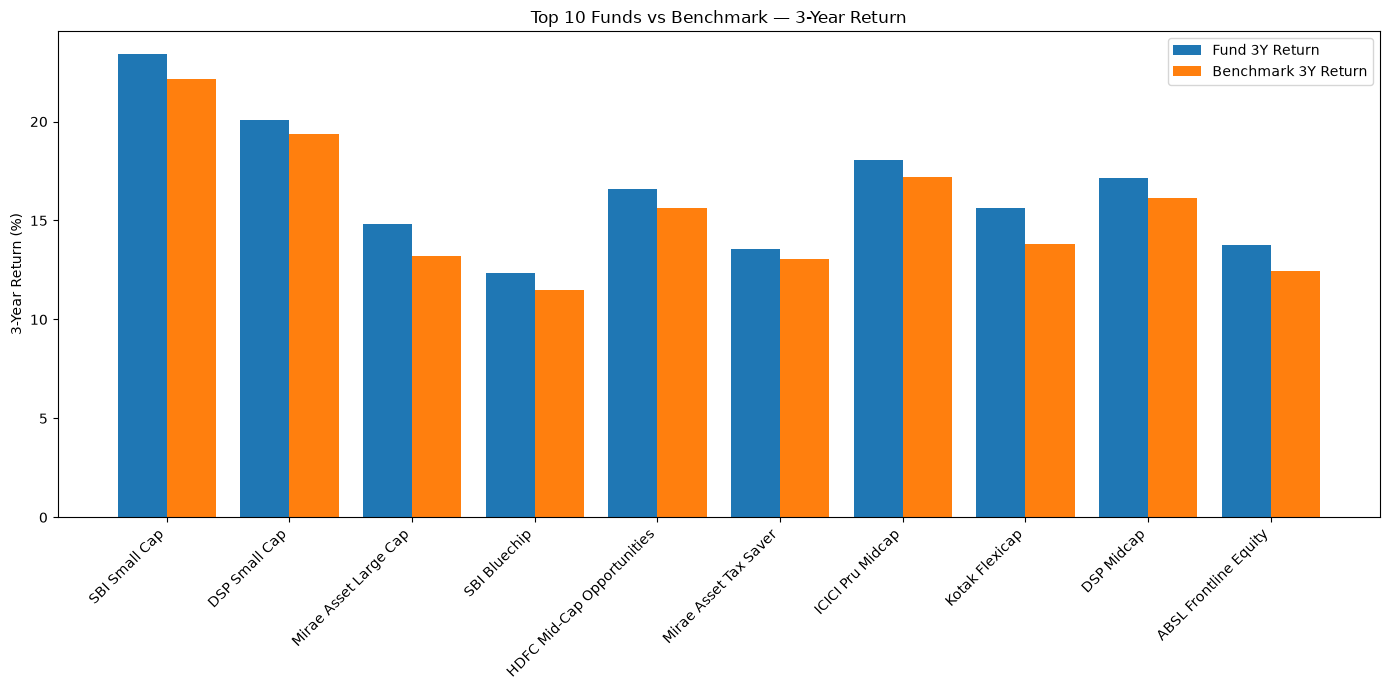

Chart saved to: ..\data\processed\benchmark_chart.png


In [43]:
# TASK 8: BENCHMARK COMPARISON CHART

import pandas as pd
import matplotlib.pyplot as plt

# Load scorecard and performance data
fund_scorecard = pd.read_csv(
    BASE_DIR / "data/processed/fund_scorecard.csv"
)

performance = pd.read_csv(
    BASE_DIR / "data/processed/07_scheme_performance_clean.csv"
)

# Select top 10 funds
top10 = (
    fund_scorecard
    .sort_values("Overall_Rank")
    .head(10)
)

# Merge with performance data
benchmark_comparison = top10.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "return_3yr_pct",
            "benchmark_3yr_pct"
        ]
    ],
    on=["amfi_code", "scheme_name"],
    how="left"
)

# Create shorter names for the chart
benchmark_comparison["short_name"] = (
    benchmark_comparison["scheme_name"]
    .str.replace(" Fund", "", regex=False)
    .str.replace(" - Regular Plan - Growth", "", regex=False)
    .str.replace(" - Regular - Growth", "", regex=False)
)

# Display comparison data
print("TOP 10 BENCHMARK COMPARISON")
display(
    benchmark_comparison[
        [
            "Overall_Rank",
            "short_name",
            "return_3yr_pct",
            "benchmark_3yr_pct"
        ]
    ]
)

# Create chart
plt.figure(figsize=(14, 7))

x = range(len(benchmark_comparison))

plt.bar(
    [i - 0.2 for i in x],
    benchmark_comparison["return_3yr_pct"],
    width=0.4,
    label="Fund 3Y Return"
)

plt.bar(
    [i + 0.2 for i in x],
    benchmark_comparison["benchmark_3yr_pct"],
    width=0.4,
    label="Benchmark 3Y Return"
)

plt.xticks(
    list(x),
    benchmark_comparison["short_name"],
    rotation=45,
    ha="right"
)

plt.ylabel("3-Year Return (%)")
plt.title("Top 10 Funds vs Benchmark — 3-Year Return")
plt.legend()
plt.tight_layout()

# Save chart
chart_path = BASE_DIR / "data/processed/benchmark_chart.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", chart_path)